# Calculate the metrics from the csv

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

# --- Define models and their respective CSV paths ---
# Updated to match the folder structure generated by make_csv.py
# (Assuming this script is run from the project root)
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_closed_image/closed_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_closed_image/closed_dist_matrix.csv"
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    # Increased 'm' to 100 for statistically sound confidence intervals
    all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")


# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename (e.g., "closed_world_results.pkl")
FILENAME = f"closed_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print("✅ Results saved successfully.")


Processing DINOv2 (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 31.16it/s]



Processing DINOv2 (Image)
-> Pre-calculating sorted match matrix...
-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 28.28it/s]



Processing SwinV2 (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping closed metrics from CSV (100 iterations)...


...


Processing ViT (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 27.83it/s]



Processing ViT (Image)
-> Pre-calculating sorted match matrix...
-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 28.85it/s]


-> Saving all results to results_data/closed_world_benchmarks.pkl...
✅ Results saved successfully.


In [2]:
# Load the saved data
LOAD_PATH = "results_data/closed_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")


Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']


In [3]:
# --- Updated Print Section (Closed World) ---
print("\n" + "="*110)
print(f"{'Model':<25} | {'mAP [95% CI]':<25} | {'Rank-1 [95% CI]':<25} | {'Rank-3 [95% CI]':<25}")
print("="*110)

for name, res in all_results.items():
    # mAP with Confidence Interval
    # Note: Ensure your aggregate function saves mAP_lower/upper (see fix below)
    m_mean = res['mAP_mean']
    m_low  = res.get('mAP_lower', 0) # Fallback if not calculated
    m_high = res.get('mAP_upper', 0)
    map_str = f"{m_mean:.3f} [{m_low:.3f}-{m_high:.3f}]"
    
    # Rank-1 (Index 0)
    r1_m = res['cmc_mean'][0]
    r1_l = res['cmc_lower'][0]
    r1_u = res['cmc_upper'][0]
    r1_str = f"{r1_m:.3f} [{r1_l:.3f}-{r1_u:.3f}]"
    
    # Rank-3 (Index 2)
    idx = 2 if len(res['cmc_mean']) >= 3 else -1
    r3_m = res['cmc_mean'][idx]
    r3_l = res['cmc_lower'][idx]
    r3_u = res['cmc_upper'][idx]
    r3_str = f"{r3_m:.3f} [{r3_l:.3f}-{r3_u:.3f}]"
    
    print(f"{name:<25} | {map_str:<25} | {r1_str:<25} | {r3_str:<25}")

print("-" * 110)


Model                     | mAP [95% CI]              | Rank-1 [95% CI]           | Rank-3 [95% CI]          
DINOv2 (Video)            | 0.528 [0.505-0.556]       | 0.560 [0.533-0.592]       | 0.692 [0.659-0.725]      
DINOv2 (Image)            | 0.432 [0.413-0.451]       | 0.433 [0.409-0.461]       | 0.594 [0.565-0.622]      
SwinV2 (Video)            | 0.253 [0.235-0.274]       | 0.241 [0.217-0.266]       | 0.371 [0.343-0.402]      
SwinV2 (Image)            | 0.197 [0.184-0.213]       | 0.180 [0.163-0.202]       | 0.295 [0.272-0.319]      
ViT (Video)               | 0.279 [0.265-0.296]       | 0.268 [0.248-0.291]       | 0.411 [0.383-0.440]      
ViT (Image)               | 0.203 [0.189-0.217]       | 0.176 [0.154-0.198]       | 0.301 [0.281-0.325]      
--------------------------------------------------------------------------------------------------------------


/tmp/ipykernel_1649771/4101439762.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


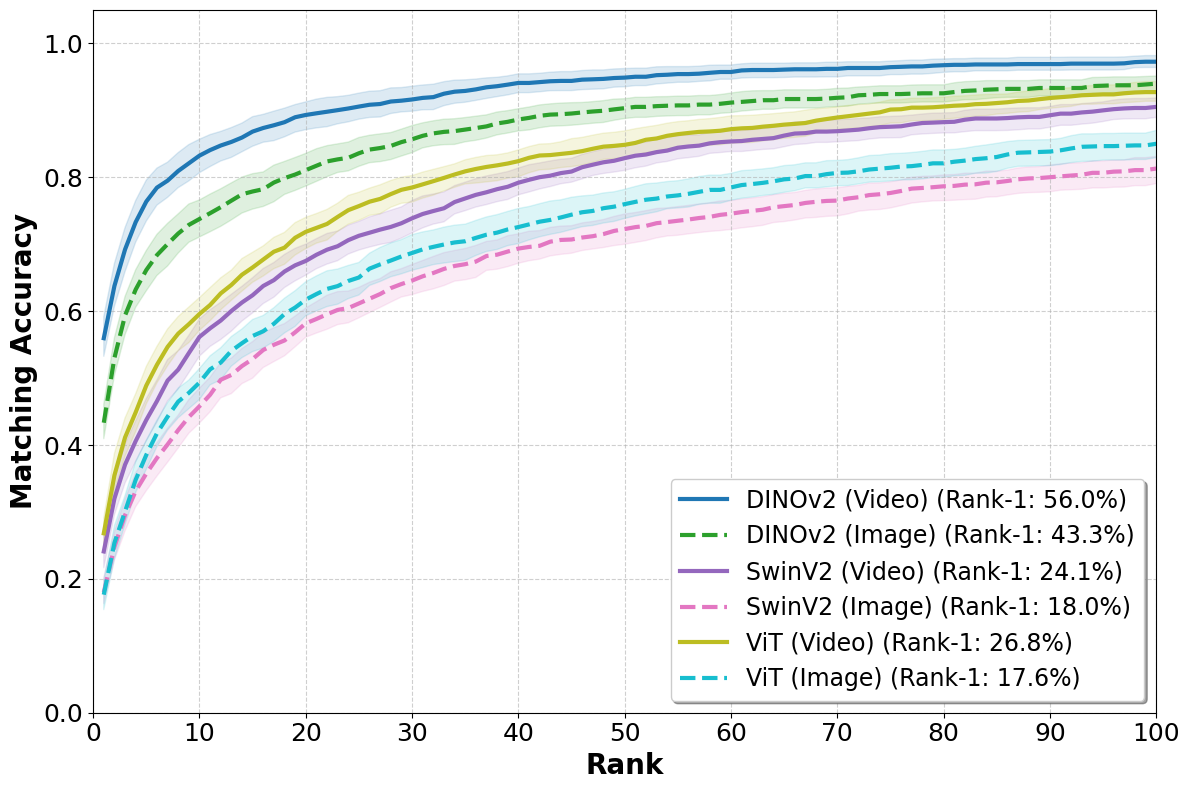


Model                     | mAP             | Rank-1 (95% CI)          
---------------------------------------------------------------------------
DINOv2 (Video)            | 52.8% ±1.2%     | 56.0% [53.3%-59.2%]      
DINOv2 (Image)            | 43.2% ±1.1%     | 43.3% [40.9%-46.1%]      
SwinV2 (Video)            | 25.3% ±1.0%     | 24.1% [21.7%-26.6%]      
SwinV2 (Image)            | 19.7% ±0.8%     | 18.0% [16.3%-20.2%]      
ViT (Video)               | 27.9% ±0.9%     | 26.8% [24.8%-29.1%]      
ViT (Image)               | 20.3% ±0.7%     | 17.6% [15.4%-19.8%]      


In [4]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# -------------------------------------------------------------
MAX_RANK = 100      
TICK_STEP = 10      # Increased step slightly for Rank-100 to avoid crowding
FONT_SIZE = 18        

# -------------------------------------------------------------
# --- Plotting CMC Curves with Confidence Intervals ---
# -------------------------------------------------------------

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab10', len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    ranks = res["ranks"]
    cmc_mean = res["cmc_mean"]
    cmc_lower = res["cmc_lower"]
    cmc_upper = res["cmc_upper"]
    color = colors(i)
    
    # 1. Plot the Shaded Uncertainty Interval (95% CI)
    plt.fill_between(ranks, cmc_lower, cmc_upper, color=color, alpha=0.15)
    
    # 2. Plot the Mean Line
    line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
    plt.plot(ranks, cmc_mean, color=color, linestyle=line_style, linewidth=3, 
             label=f"{name} (Rank-1: {cmc_mean[0]:.1%})")

# --- Format the Plot with Larger Fonts ---
plt.xlabel("Rank", fontsize=FONT_SIZE + 2, fontweight='bold')
plt.ylabel("Matching Accuracy", fontsize=FONT_SIZE + 2, fontweight='bold')

# --- Axis Tick Labels ---
plt.xticks(np.arange(0, MAX_RANK + 1, step=TICK_STEP), fontsize=FONT_SIZE)
plt.yticks(fontsize=FONT_SIZE)

# --- Dynamic Axis Control ---
plt.xlim(0, MAX_RANK) 
plt.ylim(0, 1.05)

plt.grid(True, linestyle='--', alpha=0.6)

# --- Legend Configuration ---
# Placed in lower right as CMC curves typically trend upward
plt.legend(fontsize=FONT_SIZE - 1, loc='lower right', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.show()

# --- Print Section remains identical for terminal output ---
print("\n" + "="*75)
print(f"{'Model':<25} | {'mAP':<15} | {'Rank-1 (95% CI)':<25}")
print("-" * 75)

for name, res in all_results.items():
    map_str = f"{res['mAP_mean']:.1%} ±{res['mAP_std']:.1%}"
    r1_str = f"{res['cmc_mean'][0]:.1%} [{res['cmc_lower'][0]:.1%}-{res['cmc_upper'][0]:.1%}]"
    print(f"{name:<25} | {map_str:<15} | {r1_str:<25}")